# How to deal with imbalanced datasets?

- CODE: feat: [SC] - reduce the impact of financial phrasebank imbalance [#95](https://github.com/ufdatastudio/predictions/issues/95)

---
1. ARTICLE: [Should You Use Imbalanced-Learn in 2025?](https://www.blog.trainindata.com/should-you-use-imbalanced-learn-in-2025/)
2. PAPER: [Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning](https://www.jmlr.org/papers/v18/16-365.html)

In [1]:
import os
import sys
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../'))

from data_visualizing import DataPlotting
from data_processing import DataProcessing
from feature_extraction import SpacyFeatureExtraction

In [37]:
def plot_frequency(df: pd.DataFrame, col_name: str, plot_title: str, class_names: list = None):
    # Get value counts
    counts = df[col_name].value_counts().sort_index()
    total = len(df[col_name])
    
    # Get unique class labels from dataframe
    unique_labels = sorted(df[col_name].unique())
    
    # Use provided class names or default to the actual values
    if class_names is None:
        class_names = [str(label) for label in unique_labels]
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(7, 3))
    
    # Plot bars
    bars = ax.bar(
        unique_labels, 
        counts.values, 
        color=['#1f77b4', '#ff7f0e'],
        edgecolor='black',
        width=0.6
    )
    
    # Add frequency and percentage labels above bars
    for i, (bar, count) in enumerate(zip(bars, counts.values)):
        percentage = (count / total) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'n={count}\n({percentage:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    # Customize
    ax.set_xticks(unique_labels)
    ax.set_xticklabels(class_names)
    ax.set_ylabel('Count')
    ax.set_title(f'{plot_title} Distribution')
    ax.set_ylim(0, max(counts.values) * 1.30)  # Add space for labels
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Ex 1: Synthetic data

- Comes from [1]

### Step 1: Create a synthetic imbalanced dataset

In [25]:
X, y = make_classification(
n_samples=500,
n_features=2,
n_informative=2,
n_redundant=0,
n_clusters_per_class=1,
weights=[0.9, 0.1],
flip_y=0,
random_state=42
)

In [28]:
# Correct approach
synthetic_df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
synthetic_df['Label'] = y
synthetic_df

,Feature_1,Feature_2,Label
0,-0.634459,1.196683,0
1,1.059371,0.121880,0
2,-0.346128,0.670353,0
3,-4.058955,2.498408,0
4,-1.495259,2.865142,0
...,...,...,...
495,-1.450271,0.630604,0
496,2.026043,2.720493,1
497,-0.890525,0.469038,0
498,-3.293571,1.747423,0


### Step 2: Visualize the original dataset before oversampling

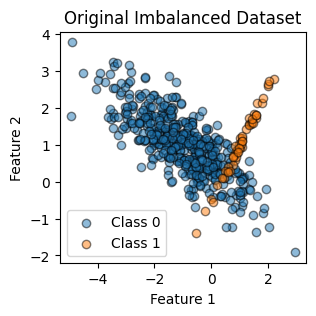

In [ ]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0", alpha=0.5, edgecolor="k")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1", alpha=0.5, edgecolor="k")
plt.title("Original Imbalanced Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

### Step 3: Apply RandomOverSampler to balance the dataset

In [ ]:
oversample = RandomOverSampler(sampling_strategy='minority', random_state=42)
oversample

RandomOverSampler(random_state=42, sampling_strategy='minority')

### Step 4: Visualize the dataset after oversampling

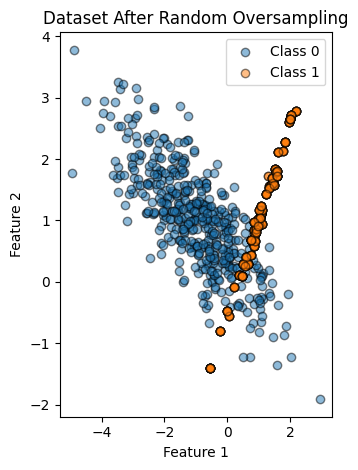

In [ ]:
X_over, y_over = oversample.fit_resample(X, y)

plt.subplot(1, 2, 2)
plt.scatter(X_over[y_over == 0][:, 0], X_over[y_over == 0][:, 1], label="Class 0", alpha=0.5, edgecolor="k")
plt.scatter(X_over[y_over == 1][:, 0], X_over[y_over == 1][:, 1], label="Class 1", alpha=0.5, edgecolor="k")
plt.title("Dataset After Random Oversampling")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
X_over

array([[-0.63445852,  1.19668341],
       [ 1.05937142,  0.12188007],
       [-0.34612842,  0.67035266],
       ...,
       [ 2.00426606,  2.64487839],
       [ 0.00438936, -0.47129556],
       [ 0.75582398,  0.67616306]])

In [34]:
# Create separate dataframe for oversampled data
synthetic_oversampled_df = pd.DataFrame(X_over, columns=['Feature_1', 'Feature_2'])
synthetic_oversampled_df['Label'] = y_over
synthetic_oversampled_df

,Feature_1,Feature_2,Label
0,-0.634459,1.196683,0
1,1.059371,0.121880,0
2,-0.346128,0.670353,0
3,-4.058955,2.498408,0
4,-1.495259,2.865142,0
...,...,...,...
895,1.626426,2.121845,1
896,0.965146,0.903895,1
897,2.004266,2.644878,1
898,0.004389,-0.471296,1


In [35]:
print(f"Original: {len(synthetic_df)} rows")
print(f"Oversampled: {len(X_over)} rows")

Original: 500 rows
Oversampled: 900 rows


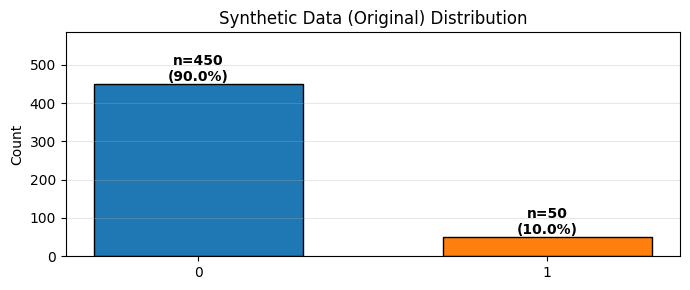

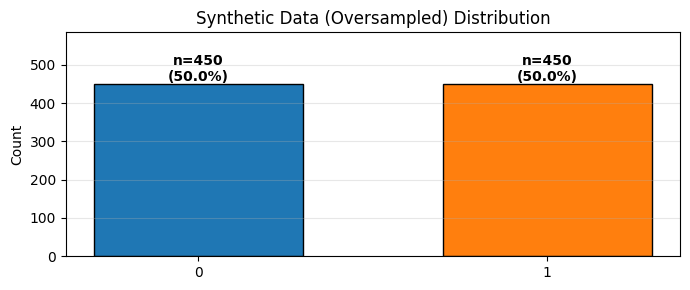

In [39]:
# Option 1: Use actual values from dataframe (0, 1)
plot_frequency(synthetic_df, 'Label', 'Synthetic Data (Original)')
plot_frequency(synthetic_oversampled_df, 'Label', 'Synthetic Data (Oversampled)')

## Experiment with Financial Phrasebank

In [6]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/annotators')
data_path = os.path.join(combine_data_path, 'maya_annotations-fpb-binary_labels-v2.csv')
df = DataProcessing.load_from_file(path=data_path, file_type='csv', sep = ",", encoding = 'latin')
df.dropna(inplace=True)
df

,Base Sentence,maya_label,Sentence Label,Author Type
0,With the new production plant the company woul...,PREDICTION,1,1
1,According to the company 's updated strategy f...,PREDICTION,1,1
2,TeliaSonera TLSN said the offer is in line wit...,PREDICTION,1,1
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...",PREDICTION,1,1
4,The company also estimates the already carried...,PREDICTION,1,1
...,...,...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,NON-PREDICTION,0,1
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,NON-PREDICTION,0,1
4843,Operating profit fell to EUR 35.4 mn from EUR ...,NON-PREDICTION,0,1
4844,Net sales of the Paper segment decreased to EU...,NON-PREDICTION,0,1


In [40]:
spacy_fe = SpacyFeatureExtraction(df, 'Base Sentence')
spacy_sentence_embeddings_df = spacy_fe.sentence_embeddings_extraction(attach_to_df=True)
spacy_sentence_embeddings_df

100%|██████████| 4846/4846 [00:19<00:00, 245.99it/s]


,Base Sentence,maya_label,Sentence Label,Author Type,Base Sentence Embedding
0,With the new production plant the company woul...,PREDICTION,1,1,"[-0.12256822, 0.24862413, -0.048265517, -0.109..."
1,According to the company 's updated strategy f...,PREDICTION,1,1,"[-0.26332003, 0.32854047, 0.04485582, -0.01094..."
2,TeliaSonera TLSN said the offer is in line wit...,PREDICTION,1,1,"[0.01150803, 0.19822516, 0.019506244, -0.05977..."
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...",PREDICTION,1,1,"[-0.005943053, 0.15729912, -0.101663664, -0.04..."
4,The company also estimates the already carried...,PREDICTION,1,1,"[-0.09756714, 0.21774293, -0.052489348, 0.0229..."
...,...,...,...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,NON-PREDICTION,0,1,"[-0.099730656, 0.1643495, 0.017135162, 0.07131..."
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,NON-PREDICTION,0,1,"[-0.19892499, 0.30014804, 0.10139055, -0.12584..."
4843,Operating profit fell to EUR 35.4 mn from EUR ...,NON-PREDICTION,0,1,"[-0.12662552, 0.28139418, 0.14707643, -0.08270..."
4844,Net sales of the Paper segment decreased to EU...,NON-PREDICTION,0,1,"[-0.13203417, 0.22406398, 0.031153306, 0.01043..."


In [49]:
# Extract embeddings and convert to array
embeddings_array = np.stack(df['Base Sentence Embedding'].values)

# Create new dataframe with first 2 dimensions and label
financial_2d_df = pd.DataFrame({
    'Feature_1': embeddings_array[:, 0],
    'Feature_2': embeddings_array[:, 1],
    'Label': df['Sentence Label']
})

financial_2d_df

,Feature_1,Feature_2,Label
0,-0.122568,0.248624,1
1,-0.263320,0.328540,1
2,0.011508,0.198225,1
3,-0.005943,0.157299,1
4,-0.097567,0.217743,1
...,...,...,...
4841,-0.099731,0.164349,0
4842,-0.198925,0.300148,0
4843,-0.126626,0.281394,0
4844,-0.132034,0.224064,0


In [50]:
print(financial_2d_df.shape)
print(financial_2d_df['Label'].value_counts())

(4846, 3)
Label
0    4388
1     458
Name: count, dtype: int64


In [45]:
filt_predictions = (spacy_sentence_embeddings_df['Sentence Label'] == 1)
predictions_df = spacy_sentence_embeddings_df[filt_predictions]
predictions_df['Sentence Label (1)'] = 1
predictions_df

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_84387/4166879316.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions_df['Sentence Label (1)'] = 1


,Base Sentence,maya_label,Sentence Label,Author Type,Base Sentence Embedding,Sentence Label (1)
0,With the new production plant the company woul...,PREDICTION,1,1,"[-0.12256822, 0.24862413, -0.048265517, -0.109...",1
1,According to the company 's updated strategy f...,PREDICTION,1,1,"[-0.26332003, 0.32854047, 0.04485582, -0.01094...",1
2,TeliaSonera TLSN said the offer is in line wit...,PREDICTION,1,1,"[0.01150803, 0.19822516, 0.019506244, -0.05977...",1
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...",PREDICTION,1,1,"[-0.005943053, 0.15729912, -0.101663664, -0.04...",1
4,The company also estimates the already carried...,PREDICTION,1,1,"[-0.09756714, 0.21774293, -0.052489348, 0.0229...",1
...,...,...,...,...,...,...
453,The company 's previous estimate was for a low...,PREDICTION,1,1,"[-0.11286265, 0.27994323, -0.016585687, -0.060...",1
454,Finnish Suominen Corporation that makes wipes ...,PREDICTION,1,1,"[-0.07125469, 0.19142334, -0.09484875, -0.0666...",1
455,The net sales of the whole fiscal year 2008 wi...,PREDICTION,1,1,"[-0.21595913, 0.24187677, 0.026175266, -0.0546...",1
456,Operating profit excluding non-recurring items...,PREDICTION,1,1,"[-0.27010173, 0.29442647, 0.024629388, -0.0121...",1


In [44]:
non_predictions_df = spacy_sentence_embeddings_df[~filt_predictions]
non_predictions_df['Sentence Label (0)'] = 0
non_predictions_df

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_84387/233198507.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_predictions_df['Sentence Label (0)'] = 0


,Base Sentence,maya_label,Sentence Label,Author Type,Base Sentence Embedding,Sentence Label (0)
458,"According to Gran , the company has no plans t...",NON-PREDICTION,0,1,"[0.027561586, 0.17978388, -0.12160311, -0.1750...",0
459,Technopolis plans to develop in stages an area...,NON-PREDICTION,0,1,"[0.023615232, 0.17563722, -0.047592126, -0.100...",0
460,The international electronic industry company ...,NON-PREDICTION,0,1,"[0.06389377, 0.10720756, 0.014266976, -0.11025...",0
461,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,NON-PREDICTION,0,1,"[-0.09132603, 0.1426104, 0.06320063, -0.127371...",0
462,"For the last quarter of 2010 , Componenta 's n...",NON-PREDICTION,0,1,"[-0.08142947, 0.26222414, -0.09313218, 0.09756...",0
...,...,...,...,...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,NON-PREDICTION,0,1,"[-0.099730656, 0.1643495, 0.017135162, 0.07131...",0
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,NON-PREDICTION,0,1,"[-0.19892499, 0.30014804, 0.10139055, -0.12584...",0
4843,Operating profit fell to EUR 35.4 mn from EUR ...,NON-PREDICTION,0,1,"[-0.12662552, 0.28139418, 0.14707643, -0.08270...",0
4844,Net sales of the Paper segment decreased to EU...,NON-PREDICTION,0,1,"[-0.13203417, 0.22406398, 0.031153306, 0.01043...",0


In [48]:
features_df = DataProcessing.concat_dfs([predictions_df, non_predictions_df])
features_df

,Base Sentence,maya_label,Sentence Label,Author Type,Base Sentence Embedding,Sentence Label (1),Sentence Label (0)
0,With the new production plant the company woul...,PREDICTION,1,1,"[-0.12256822, 0.24862413, -0.048265517, -0.109...",1.0,NaN
1,According to the company 's updated strategy f...,PREDICTION,1,1,"[-0.26332003, 0.32854047, 0.04485582, -0.01094...",1.0,NaN
2,TeliaSonera TLSN said the offer is in line wit...,PREDICTION,1,1,"[0.01150803, 0.19822516, 0.019506244, -0.05977...",1.0,NaN
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...",PREDICTION,1,1,"[-0.005943053, 0.15729912, -0.101663664, -0.04...",1.0,NaN
4,The company also estimates the already carried...,PREDICTION,1,1,"[-0.09756714, 0.21774293, -0.052489348, 0.0229...",1.0,NaN
...,...,...,...,...,...,...,...
4841,LONDON MarketWatch -- Share prices ended lower...,NON-PREDICTION,0,1,"[-0.099730656, 0.1643495, 0.017135162, 0.07131...",NaN,0.0
4842,Rinkuskiai 's beer sales fell by 6.5 per cent ...,NON-PREDICTION,0,1,"[-0.19892499, 0.30014804, 0.10139055, -0.12584...",NaN,0.0
4843,Operating profit fell to EUR 35.4 mn from EUR ...,NON-PREDICTION,0,1,"[-0.12662552, 0.28139418, 0.14707643, -0.08270...",NaN,0.0
4844,Net sales of the Paper segment decreased to EU...,NON-PREDICTION,0,1,"[-0.13203417, 0.22406398, 0.031153306, 0.01043...",NaN,0.0


In [41]:
X = spacy_sentence_embeddings_df['Base Sentence Embedding'].values
X

array([array([-1.22568220e-01,  2.48624131e-01, -4.82655168e-02, -1.09789923e-01,
              -8.58348906e-02,  3.63291465e-02, -1.27964811e-02,  7.17335939e-02,
              -1.18364163e-01,  2.27930522e+00, -3.32476139e-01, -1.46164745e-02,
               1.25499114e-01,  7.25146085e-02,  6.57393187e-02, -5.76901138e-02,
              -2.05907249e-03,  1.51917112e+00, -3.29480022e-01, -4.57408801e-02,
               2.22120117e-02,  1.05339624e-01, -4.22692373e-02, -1.23566784e-01,
              -5.79119613e-03,  6.18153140e-02, -5.48806489e-02,  2.96797305e-02,
              -1.07008472e-01, -9.98812243e-02, -9.39770564e-02,  3.87728140e-02,
              -5.82127571e-02,  7.14930072e-02,  9.65250358e-02, -3.75642404e-02,
               7.18023349e-03,  6.21852428e-02,  7.68979266e-02, -1.69069305e-01,
               1.44475931e-03,  7.71993026e-02,  3.41709815e-02, -1.10992551e-01,
              -1.81387588e-02, -8.61631632e-02, -2.34903637e-02,  6.00658916e-02,
              -3

In [ ]:
# classes_names = ['Non-Projection', 'Projection']
# # Raises ValueError with single feature
# result_df = DataProcessing.balance_data_two(
#     df=spacy_sentence_embeddings_df,
#     X_features_col_names="Base Sentence Embedding",  # Only 1 feature - will raise error if create_plot=True
#     y_labels_col_name="Sentence Label",
#     method_to_balance=RandomOverSampler,
#     create_plot=True  # This will fail
# )

In [ ]:
plot_frequency(synthetic_df, 'Sentence Label', 'Financial Phrasebank Prediction/Non-Prediction Sentence Label', 
               class_names=['NON-PREDICTION', 'PREDICTION'])

In [51]:
def extract_features_for_visualization(df: pd.DataFrame, 
                                       embedding_col: str, 
                                       label_col: str) -> pd.DataFrame:
    """
    Extract first 2 dimensions from embeddings for visualization.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing embeddings and labels.
    embedding_col : str
        Column name containing embedding vectors.
    label_col : str
        Column name containing labels.
        
    Returns
    -------
    pd.DataFrame
        DataFrame with Feature_1, Feature_2, and Label columns.
    """
    # Extract embeddings and convert to array
    embeddings_array = np.stack(df[embedding_col].values)
    
    # Create new dataframe with first 2 dimensions and label
    features_df = pd.DataFrame({
        'Feature_1': embeddings_array[:, 0],
        'Feature_2': embeddings_array[:, 1],
        'Label': df[label_col]
    })
    
    return features_df


def apply_random_oversampler(df: pd.DataFrame, 
                             feature_cols: list = ['Feature_1', 'Feature_2'],
                             label_col: str = 'Label',
                             sampling_strategy: str = 'minority',
                             random_state: int = 42) -> pd.DataFrame:
    """
    Apply RandomOverSampler to balance the dataset.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with features and labels.
    feature_cols : list
        List of feature column names.
    label_col : str
        Column name containing labels.
    sampling_strategy : str or dict or float
        Sampling strategy for RandomOverSampler.
    random_state : int
        Random seed for reproducibility.
        
    Returns
    -------
    pd.DataFrame
        Balanced DataFrame after oversampling.
    """
    # Extract features and labels
    X = df[feature_cols].values
    y = df[label_col].values
    
    # Apply oversampling
    oversample = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=random_state)
    X_over, y_over = oversample.fit_resample(X, y)
    
    # Create new dataframe
    oversampled_df = pd.DataFrame(X_over, columns=feature_cols)
    oversampled_df[label_col] = y_over
    
    return oversampled_df


def visualize_before_after_oversampling(df_before: pd.DataFrame,
                                        df_after: pd.DataFrame,
                                        label_col: str = 'Label',
                                        class_names: list = ['Class 0', 'Class 1'],
                                        feature_cols: list = ['Feature_1', 'Feature_2']) -> None:
    """
    Visualize class distribution before and after oversampling.
    
    Parameters
    ----------
    df_before : pd.DataFrame
        Original imbalanced DataFrame.
    df_after : pd.DataFrame
        Balanced DataFrame after oversampling.
    label_col : str
        Column name containing labels.
    class_names : list
        Names for the two classes.
    feature_cols : list
        Feature column names for scatter plot.
        
    Returns
    -------
    None
        Displays two plots: bar charts and scatter plots.
    """
    # Create figure with 2 rows and 2 columns
    fig = plt.figure(figsize=(14, 10))
    
    # --- Row 1: Bar charts showing class distribution ---
    
    # Before oversampling - bar chart
    ax1 = plt.subplot(2, 2, 1)
    counts_before = df_before[label_col].value_counts().sort_index()
    total_before = len(df_before[label_col])
    
    bars_before = ax1.bar(
        [0, 1],
        counts_before.values,
        color=['#1f77b4', '#ff7f0e'],
        edgecolor='black',
        width=0.6
    )
    
    for bar, count in zip(bars_before, counts_before.values):
        percentage = (count / total_before) * 100
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'n={count}\n({percentage:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(class_names)
    ax1.set_ylabel('Count')
    ax1.set_title('Before Oversampling - Class Distribution')
    ax1.set_ylim(0, max(counts_before.values) * 1.30)
    ax1.grid(axis='y', alpha=0.3)
    
    # After oversampling - bar chart
    ax2 = plt.subplot(2, 2, 2)
    counts_after = df_after[label_col].value_counts().sort_index()
    total_after = len(df_after[label_col])
    
    bars_after = ax2.bar(
        [0, 1],
        counts_after.values,
        color=['#1f77b4', '#ff7f0e'],
        edgecolor='black',
        width=0.6
    )
    
    for bar, count in zip(bars_after, counts_after.values):
        percentage = (count / total_after) * 100
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'n={count}\n({percentage:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels(class_names)
    ax2.set_ylabel('Count')
    ax2.set_title('After Oversampling - Class Distribution')
    ax2.set_ylim(0, max(counts_after.values) * 1.30)
    ax2.grid(axis='y', alpha=0.3)
    
    # --- Row 2: Scatter plots showing feature space ---
    
    # Before oversampling - scatter plot
    ax3 = plt.subplot(2, 2, 3)
    X_before = df_before[feature_cols].values
    y_before = df_before[label_col].values
    
    ax3.scatter(
        X_before[y_before == 0][:, 0], X_before[y_before == 0][:, 1],
        label=class_names[0], alpha=0.5, edgecolor='k'
    )
    ax3.scatter(
        X_before[y_before == 1][:, 0], X_before[y_before == 1][:, 1],
        label=class_names[1], alpha=0.5, edgecolor='k'
    )
    ax3.set_title(f'Before Oversampling - Feature Space\n(n={len(df_before)})')
    ax3.set_xlabel(feature_cols[0])
    ax3.set_ylabel(feature_cols[1])
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # After oversampling - scatter plot
    ax4 = plt.subplot(2, 2, 4)
    X_after = df_after[feature_cols].values
    y_after = df_after[label_col].values
    
    ax4.scatter(
        X_after[y_after == 0][:, 0], X_after[y_after == 0][:, 1],
        label=class_names[0], alpha=0.5, edgecolor='k'
    )
    ax4.scatter(
        X_after[y_after == 1][:, 0], X_after[y_after == 1][:, 1],
        label=class_names[1], alpha=0.5, edgecolor='k'
    )
    ax4.set_title(f'After Oversampling - Feature Space\n(n={len(df_after)})')
    ax4.set_xlabel(feature_cols[0])
    ax4.set_ylabel(feature_cols[1])
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [52]:
# Step 1: Extract features for visualization
financial_2d_df = extract_features_for_visualization(
    df=df,
    embedding_col='Base Sentence Embedding',
    label_col='Sentence Label'
)
financial_2d_df

,Feature_1,Feature_2,Label
0,-0.122568,0.248624,1
1,-0.263320,0.328540,1
2,0.011508,0.198225,1
3,-0.005943,0.157299,1
4,-0.097567,0.217743,1
...,...,...,...
4841,-0.099731,0.164349,0
4842,-0.198925,0.300148,0
4843,-0.126626,0.281394,0
4844,-0.132034,0.224064,0


In [54]:
# Step 2: Apply oversampling
financial_oversampled_df = apply_random_oversampler(
    df=financial_2d_df,
    feature_cols=['Feature_1', 'Feature_2'],
    label_col='Label',
    sampling_strategy='minority'
)
financial_oversampled_df

,Feature_1,Feature_2,Label
0,-0.122568,0.248624,1
1,-0.263320,0.328540,1
2,0.011508,0.198225,1
3,-0.005943,0.157299,1
4,-0.097567,0.217743,1
...,...,...,...
8771,-0.121444,0.261572,1
8772,0.265637,-0.021337,1
8773,-0.137375,0.258408,1
8774,-0.069004,0.205301,1


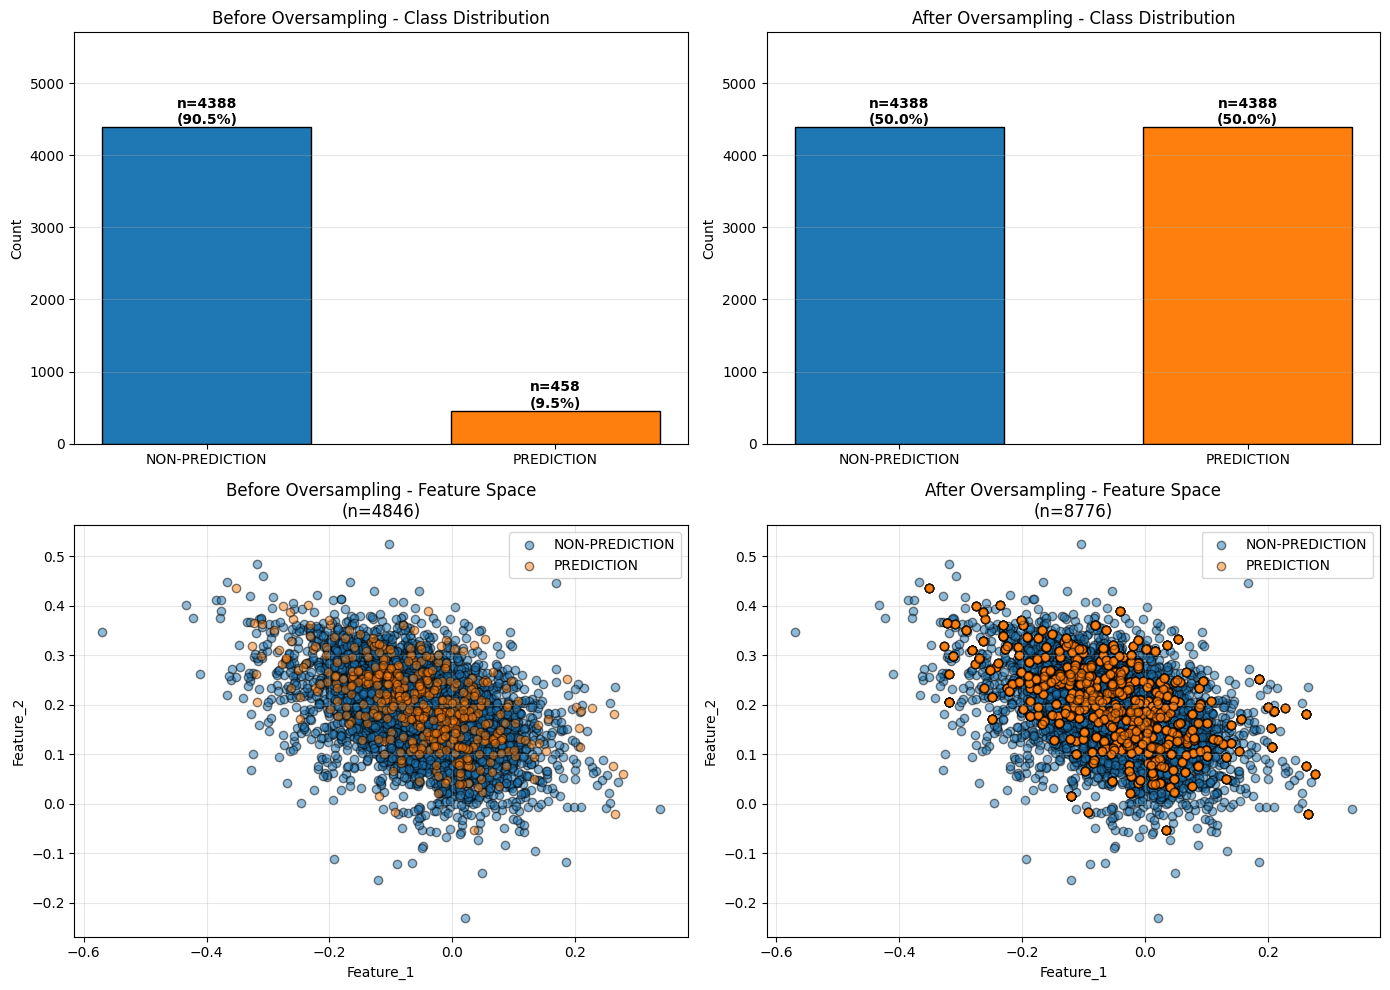

In [55]:
# Step 3: Visualize before and after
visualize_before_after_oversampling(
    df_before=financial_2d_df,
    df_after=financial_oversampled_df,
    label_col='Label',
    class_names=['NON-PREDICTION', 'PREDICTION']
)